# Unsupervised Learning — Patient Clustering

Pipeline: Data → FAMD normalisation → SVD reduction → K selection → K-Means → Profiling


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans

SEED = 42
np.random.seed(SEED)

def resolve_dataset_dir() -> Path:
    cwd = Path.cwd()
    if (cwd / 'dataset' / 'patient_features.csv').exists():
        return cwd / 'dataset'
    if cwd.name == 'unsupervised' and (cwd.parent / 'dataset' / 'patient_features.csv').exists():
        return cwd.parent / 'dataset'
    raise FileNotFoundError('Cannot find dataset/patient_features.csv')

DATASET_DIR = resolve_dataset_dir()
df = pd.read_csv(DATASET_DIR / 'patient_features.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')


Loaded: 100,000 rows × 113 columns


In [2]:
# ── Step 1: FAMD normalisation ───────────────────────────────────────────
# FAMD (Factor Analysis of Mixed Data) scales continuous and binary features
# to be comparable before applying SVD, rather than running plain PCA on raw
# one-hot columns (which would be dominated by high-prevalence flags).
#
# Continuous features  : standard z-score
# Binary/one-hot features: (x - p) / sqrt(p*(1-p))  — equalises variance
#                          regardless of how rare/common the condition is
# Block weighting      : divide each block by sqrt(its feature count) so
#                        neither block dominates by sheer number of columns

patient_ids = df['patient_id'].values
X_raw = df.drop(columns=['patient_id']).copy()
X_raw = X_raw.apply(pd.to_numeric, errors='coerce').fillna(0)

nuniq       = X_raw.nunique()
binary_cols = X_raw.columns[nuniq <= 2].tolist()   # one-hot / disease flag columns
cont_cols   = X_raw.columns[nuniq  > 2].tolist()   # continuous columns

X_cont    = StandardScaler().fit_transform(X_raw[cont_cols].values)

X_bin_raw  = X_raw[binary_cols].values.astype(float)
p          = X_bin_raw.mean(axis=0)
scale_bin  = np.maximum(np.sqrt(p * (1 - p)), 0.1)  # floor prevents extreme amplification
X_bin      = (X_bin_raw - p) / scale_bin

X_scaled = np.hstack([X_cont / np.sqrt(len(cont_cols)),
                      X_bin  / np.sqrt(len(binary_cols))])
X_scaled = np.clip(X_scaled, -5, 5)
X_scaled = np.nan_to_num(X_scaled, nan=0.0)

# Fit full PCA on FAMD-normalised matrix to compute variance ratios
# (no dimensionality reduction yet — only used to choose n_components below)
pca_full = PCA(random_state=SEED).fit(X_scaled)

print(f'Continuous features   : {len(cont_cols)}')
print(f'Binary/one-hot features: {len(binary_cols)}')
print(f'FAMD-normalised shape  : {X_scaled.shape}')


Continuous features   : 51
Binary/one-hot features: 61
FAMD-normalised shape  : (100000, 112)


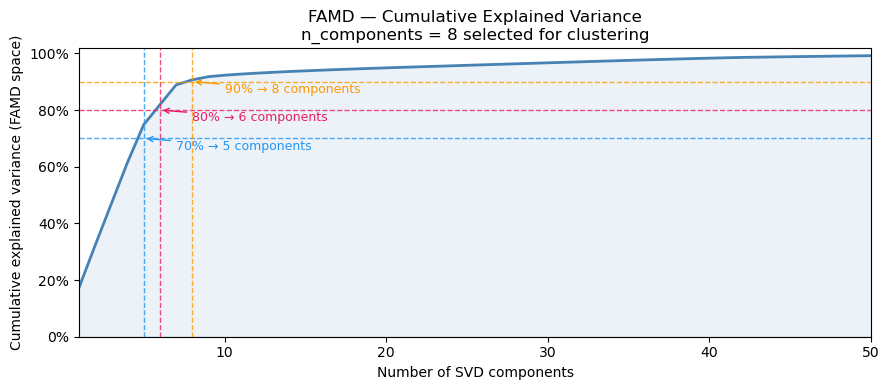

n_components chosen: 8  (explains 90.7% of FAMD variance)


In [3]:
# ── Step 2: choose n_components from FAMD variance curve ─────────────────
# pca_full was fit on X_scaled (the FAMD-normalised matrix) in the cell above.
# The cumulative variance here reflects how many SVD components are needed to
# reconstruct the FAMD-normalised representation — not raw feature variance.
# We choose the smallest n such that cumulative variance >= 80%.

cumvar     = np.cumsum(pca_full.explained_variance_ratio_)
thresholds = [0.70, 0.80, 0.90]
colors_t   = ['#2196F3', '#E91E63', '#FF9800']

n_components = 8   # manually set (80% threshold gives 6; 8 chosen for richer representation)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, color='steelblue', linewidth=2)
ax.fill_between(range(1, len(cumvar) + 1), cumvar, alpha=0.1, color='steelblue')

for thr, col in zip(thresholds, colors_t):
    n = int(np.argmax(cumvar >= thr)) + 1
    ax.axhline(thr, color=col, linestyle='--', linewidth=1, alpha=0.8)
    ax.axvline(n,   color=col, linestyle='--', linewidth=1, alpha=0.8)
    ax.annotate(f'{int(thr*100)}% → {n} components',
                xy=(n, thr), xytext=(n + 2, thr - 0.04),
                fontsize=9, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=1))

ax.set_xlabel('Number of SVD components')
ax.set_ylabel('Cumulative explained variance (FAMD space)')
ax.set_title('FAMD — Cumulative Explained Variance\n'
             f'n_components = {n_components} selected for clustering')
ax.set_xlim(1, min(50, len(cumvar)))
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

print(f'n_components chosen: {n_components}  '
      f'(explains {cumvar[n_components-1]:.1%} of FAMD variance)')


In [4]:
# ── Step 3: SVD dimensionality reduction → X_red ─────────────────────────
# Apply PCA with the chosen n_components to the FAMD-normalised matrix.
# X_red is the low-dimensional representation used for all clustering below.
# This step completes the FAMD pipeline:
#   raw features → FAMD normalise → SVD reduce → X_red

pca   = PCA(n_components=n_components, random_state=SEED)
X_red = pca.fit_transform(X_scaled)

print(f'X_scaled : {X_scaled.shape}  (FAMD-normalised, 113 features)')
print(f'X_red    : {X_red.shape}   (SVD-reduced, used for clustering)')
print(f'Variance retained: {pca.explained_variance_ratio_.sum():.1%}')


X_scaled : (100000, 112)  (FAMD-normalised, 113 features)
X_red    : (100000, 8)   (SVD-reduced, used for clustering)
Variance retained: 90.7%


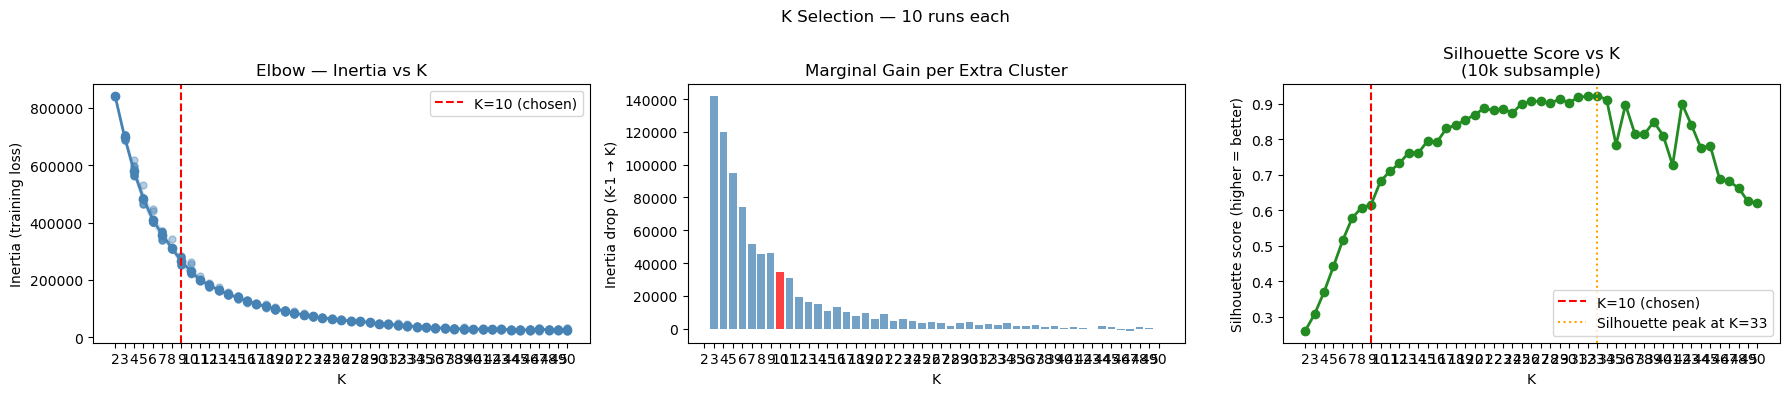

K  |  Mean Inertia  |  Silhouette
──────────────────────────────────────
 2 |      840,395  |  0.2595
 3 |      698,265  |  0.3066
 4 |      578,521  |  0.3684
 5 |      483,715  |  0.4410
 6 |      409,549  |  0.5153
 7 |      358,139  |  0.5778
 8 |      312,406  |  0.6070
 9 |      266,249  |  0.6152
10 |      231,690  |  0.6811 ← chosen
11 |      200,485  |  0.7093
12 |      181,323  |  0.7313
13 |      165,021  |  0.7618
14 |      150,232  |  0.7600
15 |      139,305  |  0.7950
16 |      126,367  |  0.7918
17 |      116,362  |  0.8298
18 |      108,421  |  0.8398
19 |       98,545  |  0.8530
20 |       92,836  |  0.8689
21 |       84,002  |  0.8862
22 |       79,081  |  0.8807
23 |       72,914  |  0.8839
24 |       68,483  |  0.8736
25 |       64,735  |  0.8993
26 |       60,944  |  0.9057
27 |       57,428  |  0.9070
28 |       55,775  |  0.9010
29 |       52,247  |  0.9121
30 |       47,951  |  0.9024
31 |       45,887  |  0.9177
32 |       43,040  |  0.9202
33 |       40,964  

In [5]:
# ── K selection: multi-run inertia + silhouette ───────────────────────────
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 51)
N_RUNS  = 10

all_inertias = {}
sil_scores   = {}

# Subsample for silhouette (10k — full 100k is too slow)
idx_sil = np.random.choice(len(X_red), size=10_000, replace=False)
X_sil   = X_red[idx_sil]

for k in K_RANGE:
    runs = [MiniBatchKMeans(n_clusters=k, random_state=SEED+r,
                            batch_size=10_000, n_init=10, max_iter=500
                            ).fit(X_red).inertia_
            for r in range(N_RUNS)]
    all_inertias[k] = runs
    # silhouette on subsample with a single fit
    km_s = MiniBatchKMeans(n_clusters=k, random_state=SEED,
                           batch_size=10_000, n_init=3, max_iter=500).fit(X_red)
    sil_scores[k] = silhouette_score(X_sil, km_s.predict(X_sil))

k_list = list(K_RANGE)
means  = [np.mean(all_inertias[k]) for k in k_list]
stds   = [np.std(all_inertias[k])  for k in k_list]
drops  = [means[i-1] - means[i] for i in range(1, len(means))]
sils   = [sil_scores[k] for k in k_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: loss curve
ax = axes[0]
for k in k_list:
    ax.scatter([k]*N_RUNS, all_inertias[k], color='steelblue', alpha=0.4, s=25)
ax.plot(k_list, means, marker='o', color='steelblue', linewidth=2)
ax.fill_between(k_list, [m-s for m,s in zip(means,stds)],
                         [m+s for m,s in zip(means,stds)],
                alpha=0.15, color='steelblue')
ax.axvline(9, color='red', linestyle='--', label='K=10 (chosen)')
ax.set_xlabel('K'); ax.set_ylabel('Inertia (training loss)')
ax.set_title('Elbow — Inertia vs K'); ax.set_xticks(k_list); ax.legend()

# Panel 2: marginal gain
ax2 = axes[1]
colors_bar = ['red' if k==10 else 'steelblue' for k in k_list[1:]]
ax2.bar(k_list[1:], drops, color=colors_bar, alpha=0.75)
ax2.set_xlabel('K'); ax2.set_ylabel('Inertia drop (K-1 → K)')
ax2.set_title('Marginal Gain per Extra Cluster'); ax2.set_xticks(k_list)

# Panel 3: silhouette score
ax3 = axes[2]
ax3.plot(k_list, sils, marker='o', color='forestgreen', linewidth=2)
ax3.axvline(9, color='red', linestyle='--', label='K=10 (chosen)')
best_sil_k = k_list[int(np.argmax(sils))]
ax3.axvline(best_sil_k, color='orange', linestyle=':', linewidth=1.5,
            label=f'Silhouette peak at K={best_sil_k}')
ax3.set_xlabel('K'); ax3.set_ylabel('Silhouette score (higher = better)')
ax3.set_title('Silhouette Score vs K\n(10k subsample)'); ax3.set_xticks(k_list); ax3.legend()

plt.suptitle(f'K Selection — {N_RUNS} runs each', fontsize=12)
plt.tight_layout()
plt.show()

print('K  |  Mean Inertia  |  Silhouette')
print('─' * 38)
for k, m, s in zip(k_list, means, sils):
    mark = ' ← chosen' if k == 10 else ''
    print(f'{k:2d} | {m:>12,.0f}  |  {s:.4f}{mark}')


In [6]:
# ── Final clustering: K=10 ────────────────────────────────────────────────
BEST_K = 10

km = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10, max_iter=300)
cluster_labels = km.fit_predict(X_red)
df['cluster']  = cluster_labels

print('Cluster distribution:')
counts = pd.Series(cluster_labels).value_counts().sort_index()
for c, n in counts.items():
    print(f'  Cluster {c}: {n:>7,} patients ({n/len(df)*100:.1f}%)')

# Save
out_path = DATASET_DIR / 'patient_clusters.csv'
df[['patient_id', 'cluster']].to_csv(out_path, index=False)
print(f'\nSaved → {out_path}')


Cluster distribution:
  Cluster 0:  11,550 patients (11.6%)
  Cluster 1:  12,309 patients (12.3%)
  Cluster 2:  22,541 patients (22.5%)
  Cluster 3:  12,889 patients (12.9%)
  Cluster 4:   7,940 patients (7.9%)
  Cluster 5:  13,795 patients (13.8%)
  Cluster 6:   9,724 patients (9.7%)
  Cluster 7:   2,813 patients (2.8%)
  Cluster 8:   3,580 patients (3.6%)
  Cluster 9:   2,859 patients (2.9%)

Saved → /Users/wangyuxin/Desktop/projects/ml_project/dataset/patient_clusters.csv


## Internal Clustering Validation

After fitting K-Means, we evaluate cluster quality using three standard **internal** validation metrics — "internal" means they rely only on the data and cluster assignments, with no ground-truth labels required.

| Metric | What it measures | Better when |
|---|---|---|
| **Silhouette score** | For each point: how much closer it is to its own cluster than to the nearest other cluster. Averages over all points. Range −1 to +1. | Higher |
| **Davies-Bouldin index** | Average ratio of within-cluster scatter to between-cluster separation. A lower value means clusters are compact and well-separated. | Lower |
| **Calinski-Harabasz index** | Ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate dense, well-separated clusters. | Higher |

All three metrics are computed on a 10,000-patient subsample for speed (full 100k is computationally expensive for silhouette).


In [7]:
# ── Internal validation metrics — K-Means ────────────────────────────────
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from IPython.display import display

idx10k = np.random.choice(len(X_red), size=10_000, replace=False)

km_metrics = {
    'Silhouette Score':        silhouette_score(X_red[idx10k], cluster_labels[idx10k]),
    'Davies-Bouldin Index':    davies_bouldin_score(X_red[idx10k], cluster_labels[idx10k]),
    'Calinski-Harabasz Index': calinski_harabasz_score(X_red[idx10k], cluster_labels[idx10k]),
}
mdf = pd.DataFrame({'K-Means (K=10)': km_metrics}).T.round(4)
display(mdf.style
    .set_caption('Internal validation — K-Means (10k subsample, 8-D feature space)')
    .set_table_styles([
        {'selector':'th','props':[('text-align','center'),('font-size','11px')]},
        {'selector':'td','props':[('text-align','center'),('font-size','11px')]},
    ]))


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
K-Means (K=10),0.681800,0.762200,3970.287600


In [8]:
# ── Cluster profiles: z-score across clusters ────────────────────────────
profile_cols = df.select_dtypes(include='number').columns.difference(['cluster']).tolist()
profile = df.groupby('cluster')[profile_cols].mean(numeric_only=True)
pz = (profile - profile.mean()) / (profile.std() + 1e-9)

TOP_N = 3
palette = sns.color_palette('tab10', BEST_K)

def make_name(c):
    tops = pz.loc[c].abs().nlargest(TOP_N)
    parts = []
    for f in tops.index:
        arrow = 'up' if pz.loc[c, f] > 0 else 'down'
        label = f.replace('dx_', '').replace('_', ' ')
        parts.append(('up ' if arrow=='up' else 'down ') + label)
    return ' | '.join(parts)

cluster_names = {c: make_name(c) for c in range(BEST_K)}


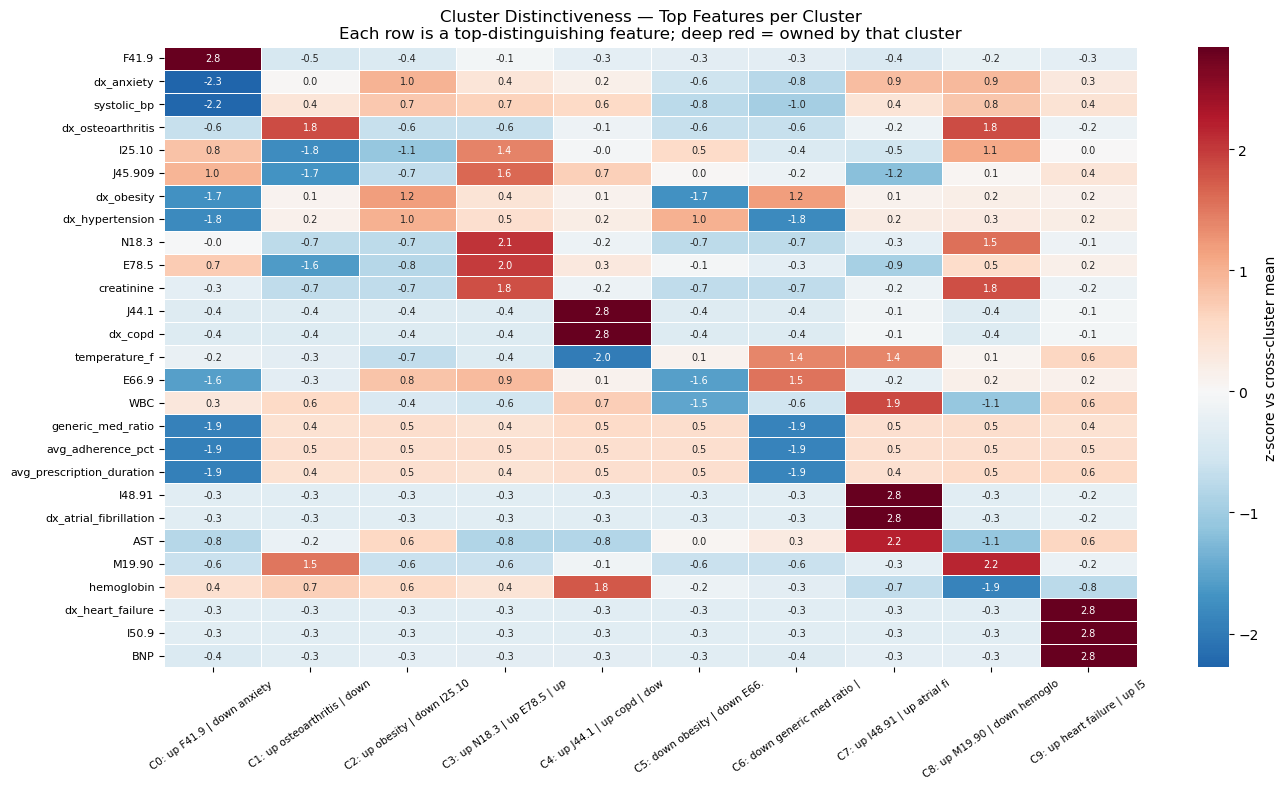

In [9]:
# ── Cluster distinctiveness heatmap ──────────────────────────────────────
from IPython.display import display

# Union of top-N features per cluster
top_feats = []
for c in range(BEST_K):
    top_feats += pz.loc[c].abs().nlargest(TOP_N).index.tolist()
top_feats = list(dict.fromkeys(top_feats))

short_names = [f'C{c}: {cluster_names[c][:24]}' for c in range(BEST_K)]
pz_focus = pz[top_feats].copy()
pz_focus.index = short_names

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pz_focus.T, cmap='RdBu_r', center=0, linewidths=0.4,
            annot=True, fmt='.1f', annot_kws={'size': 7},
            ax=ax, cbar_kws={'label': 'z-score vs cross-cluster mean'})
ax.set_title('Cluster Distinctiveness — Top Features per Cluster\n'
             'Each row is a top-distinguishing feature; deep red = owned by that cluster')
ax.tick_params(axis='x', labelsize=7.5, rotation=35)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()


Running UMAP (~2 min)...


Done.


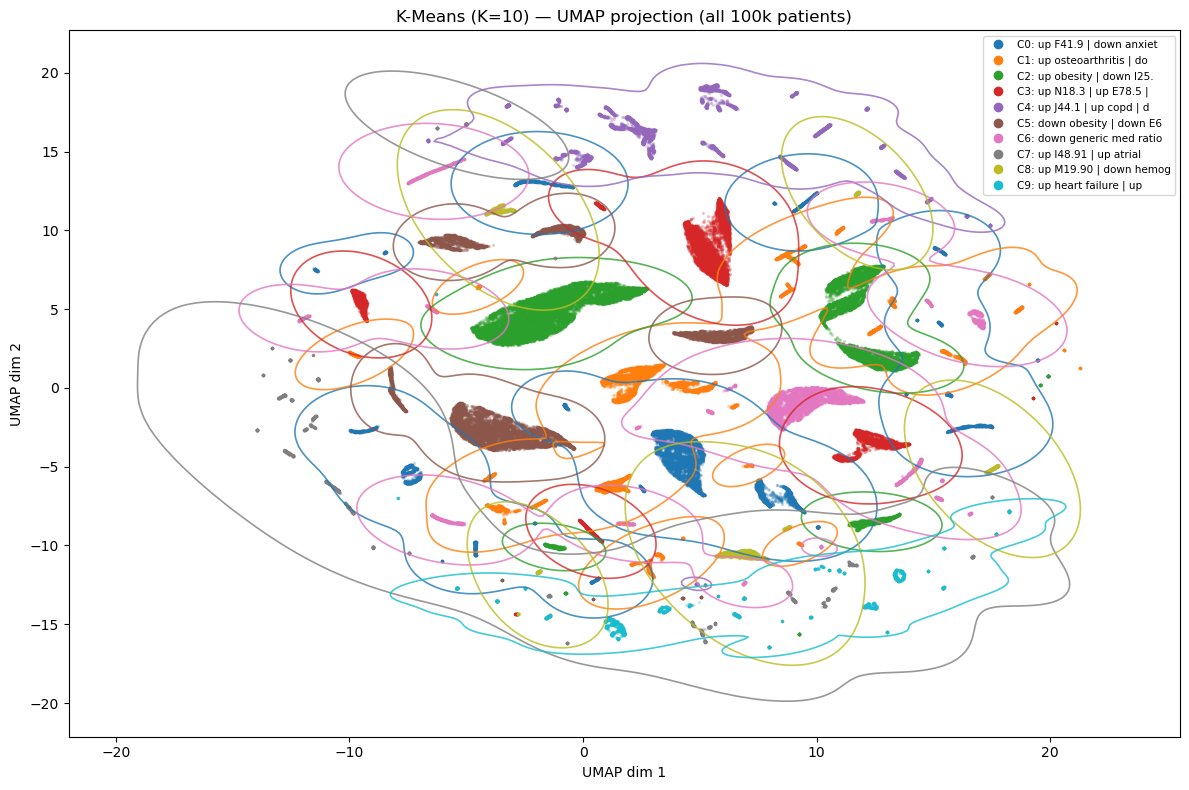

In [10]:
# ── UMAP projection + K-Means 2-D scatter ────────────────────────────────
# UMAP on X_red (8-D SVD space) rather than PCA on raw/FAMD features:
# - Preserves local cluster structure better than linear PCA
# - Avoids the PCA-on-one-hot issue (even after FAMD normalisation,
#   binary features are not Gaussian; UMAP makes no such assumption)
import umap
from matplotlib.lines import Line2D

print('Running UMAP (~2 min)...')
reducer  = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                     metric='euclidean', random_state=SEED, verbose=False)
X_umap   = reducer.fit_transform(X_red)
print('Done.')

fig, ax = plt.subplots(figsize=(12, 8))
for c in range(BEST_K):
    mask = cluster_labels == c
    xy   = X_umap[mask]
    ax.scatter(xy[:, 0], xy[:, 1], s=2, alpha=0.2,
               color=palette[c], rasterized=True)
    if mask.sum() > 200:
        try:
            sns.kdeplot(x=xy[:, 0], y=xy[:, 1], ax=ax,
                        color=palette[c], levels=2, linewidths=1.2, alpha=0.8)
        except Exception:
            pass

handles = [Line2D([0],[0], marker='o', color='w',
                  markerfacecolor=palette[c], markersize=8,
                  label=f'C{c}: {cluster_names[c][:22]}')
           for c in range(BEST_K)]
ax.legend(handles=handles, fontsize=7.5, loc='best', framealpha=0.8)
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')
ax.set_title('K-Means (K=10) — UMAP projection (all 100k patients)')
plt.tight_layout()
plt.show()


## Observations from the 2-D Projection

From the scatter plot above, a few limitations of K-Means become visible:

1. **Cluster boundaries overlap significantly in 2D.** Several clusters (e.g. C0, C3, C5) have heavily interleaved point clouds with no clear separation. While some of this is expected from projecting 8 dimensions down to 2, it also reflects that K-Means draws straight Voronoi boundaries in the original space — even when the true density boundary is curved or irregular.

2. **Cluster sizes are unequal.** C2 (22.5%) is nearly 8× larger than C7 (2.8%). K-Means penalises large deviations from its implicit assumption of equal-sized, spherical clusters, which may cause it to split some natural groupings and merge others.

3. **No notion of uncertainty.** Every patient is hard-assigned to exactly one cluster. Patients near the boundary between two clusters receive the same confident label as patients deep inside a cluster core.

These observations motivate trying **Gaussian Mixture Models (GMM)**, which relax the spherical-cluster assumption and produce soft probabilistic assignments.


## Gaussian Mixture Model (GMM)


Low-confidence patients (max prob < 80%): 12 (0.01%)


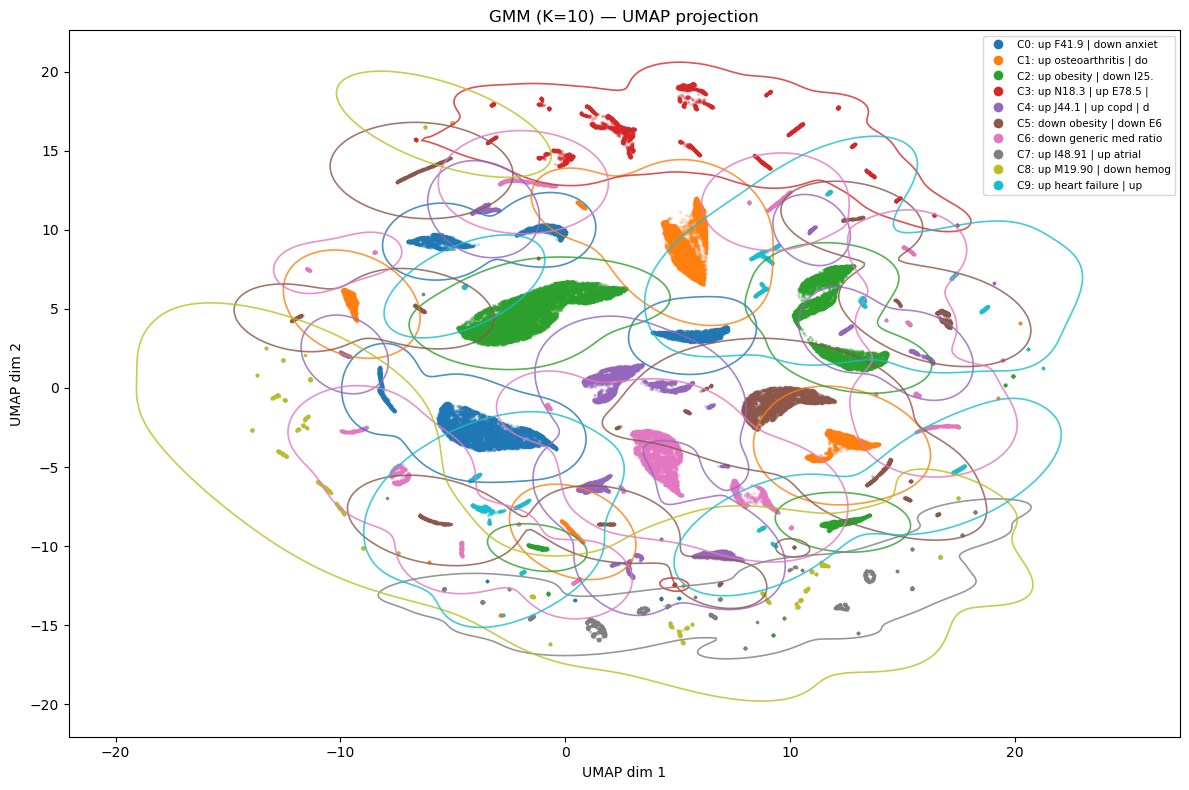

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
GMM (K=10),0.688700,0.799300,3966.825400


In [11]:
# ── GMM fit + scatter + metrics ───────────────────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from matplotlib.lines import Line2D
from IPython.display import display

gmm        = GaussianMixture(n_components=BEST_K, covariance_type='full',
                             random_state=SEED, max_iter=300, n_init=5)
gmm.fit(X_red)
gmm_labels = gmm.predict(X_red)
gmm_probs  = gmm.predict_proba(X_red)
max_probs  = gmm_probs.max(axis=1)
low_conf   = (max_probs < 0.8).sum()
print(f'Low-confidence patients (max prob < 80%): {low_conf:,} ({low_conf/len(df)*100:.2f}%)')

# Scatter (same style as K-Means cell)
fig, ax = plt.subplots(figsize=(12, 8))
for c in range(BEST_K):
    mask = gmm_labels == c
    xy   = X_umap[mask]
    ax.scatter(xy[:, 0], xy[:, 1], s=2, alpha=0.2, color=palette[c], rasterized=True)
    if mask.sum() > 200:
        try:
            sns.kdeplot(x=xy[:, 0], y=xy[:, 1], ax=ax,
                        color=palette[c], levels=2, linewidths=1.2, alpha=0.8)
        except Exception:
            pass
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[c],
                  markersize=8, label=f'C{c}: {cluster_names[c][:22]}')
           for c in range(BEST_K)]
ax.legend(handles=handles, fontsize=7.5, loc='best', framealpha=0.8)
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')
ax.set_title('GMM (K=10) — UMAP projection')
plt.tight_layout(); plt.show()

# Metrics (8-D feature space, same space as K-Means)
idx10k = np.random.choice(len(X_red), size=10_000, replace=False)
gmm_metrics = {
    'Silhouette Score':        silhouette_score(X_red[idx10k], gmm_labels[idx10k]),
    'Davies-Bouldin Index':    davies_bouldin_score(X_red[idx10k], gmm_labels[idx10k]),
    'Calinski-Harabasz Index': calinski_harabasz_score(X_red[idx10k], gmm_labels[idx10k]),
}
mdf = pd.DataFrame({'GMM (K=10)': gmm_metrics}).T.round(4)
display(mdf.style
    .set_caption('Internal validation — GMM (10k subsample, 8-D feature space)')
    .set_table_styles([
        {'selector':'th','props':[('text-align','center'),('font-size','11px')]},
        {'selector':'td','props':[('text-align','center'),('font-size','11px')]},
    ]))


HDBSCAN found 96 clusters
Noise points: 3,503  (3.5%)


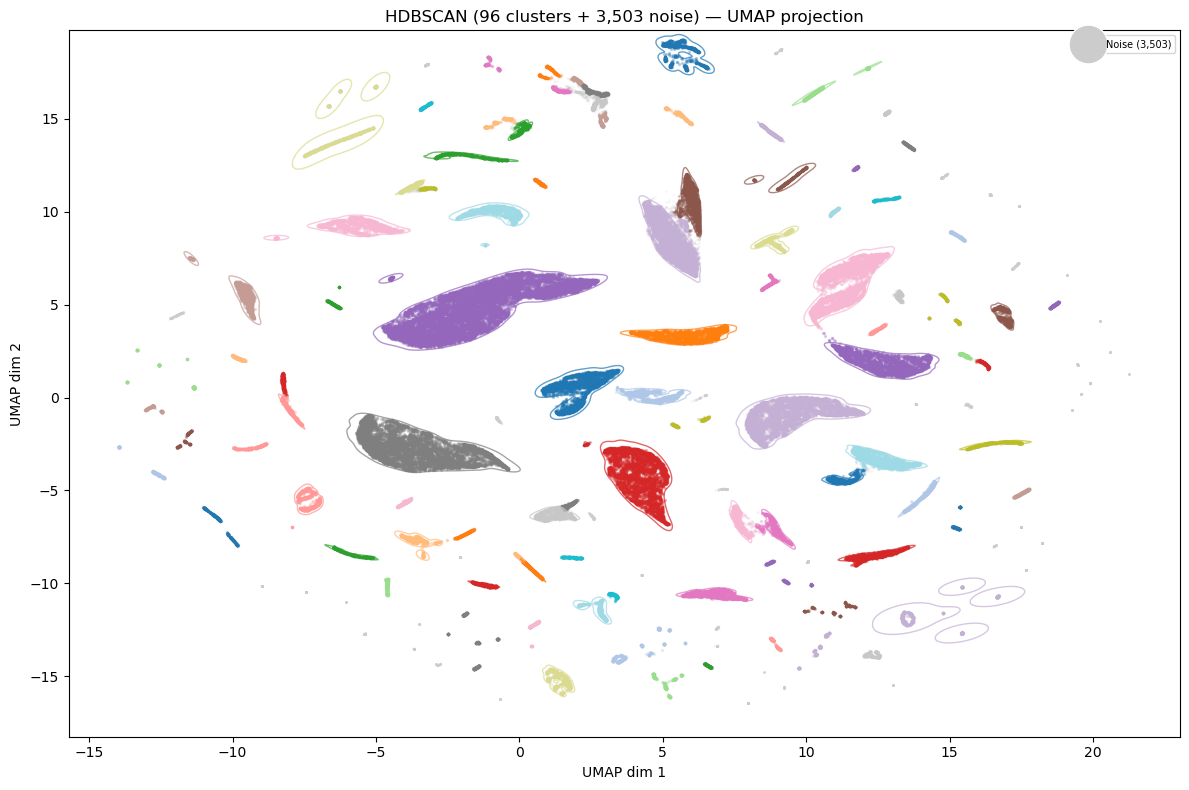

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
"HDBSCAN (96 clusters, noise excl.)",0.107900,1.957000,1447.078100


In [12]:
# ── HDBSCAN + scatter + metrics ───────────────────────────────────────────
import hdbscan as hdbscan_lib
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from matplotlib.lines import Line2D
from IPython.display import display

clusterer  = hdbscan_lib.HDBSCAN(min_cluster_size=200, min_samples=50,
                                  cluster_selection_method='eom', prediction_data=True)
hdb_labels = clusterer.fit_predict(X_umap)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise    = (hdb_labels == -1).sum()
print(f'HDBSCAN found {n_clusters} clusters')
print(f'Noise points: {n_noise:,}  ({n_noise/len(hdb_labels)*100:.1f}%)')

# Scatter (same style; grey for noise)
hdb_palette = sns.color_palette('tab20', n_clusters)
fig, ax = plt.subplots(figsize=(12, 8))
noise_mask = hdb_labels == -1
ax.scatter(X_umap[noise_mask, 0], X_umap[noise_mask, 1],
           s=1, alpha=0.1, color='#cccccc', rasterized=True, label=f'Noise ({n_noise:,})')
for ci, c in enumerate(sorted(set(hdb_labels) - {-1})):
    mask = hdb_labels == c
    col  = hdb_palette[ci % len(hdb_palette)]
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               s=2, alpha=0.25, color=col, rasterized=True)
    if mask.sum() > 500:
        try:
            sns.kdeplot(x=X_umap[mask, 0], y=X_umap[mask, 1], ax=ax,
                        color=col, levels=2, linewidths=1.0, alpha=0.7)
        except Exception:
            pass
ax.legend(fontsize=7, loc='upper right', markerscale=4,
          handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor='#cccccc',
                          markersize=7, label=f'Noise ({n_noise:,})')])
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')
ax.set_title(f'HDBSCAN ({n_clusters} clusters + {n_noise:,} noise) — UMAP projection')
plt.tight_layout(); plt.show()

# Metrics — evaluated in 8-D feature space to match K-Means/GMM
mask_valid = hdb_labels != -1
idx_hdb = np.random.choice(np.where(mask_valid)[0], size=10_000, replace=False)
hdb_metrics = {
    'Silhouette Score':        silhouette_score(X_red[idx_hdb], hdb_labels[idx_hdb]),
    'Davies-Bouldin Index':    davies_bouldin_score(X_red[idx_hdb], hdb_labels[idx_hdb]),
    'Calinski-Harabasz Index': calinski_harabasz_score(X_red[idx_hdb], hdb_labels[idx_hdb]),
}
mdf = pd.DataFrame({f'HDBSCAN ({n_clusters} clusters, noise excl.)': hdb_metrics}).T.round(4)
display(mdf.style
    .set_caption('Internal validation — HDBSCAN (10k subsample, 8-D feature space, noise excluded)')
    .set_table_styles([
        {'selector':'th','props':[('text-align','center'),('font-size','11px')]},
        {'selector':'td','props':[('text-align','center'),('font-size','11px')]},
    ]))


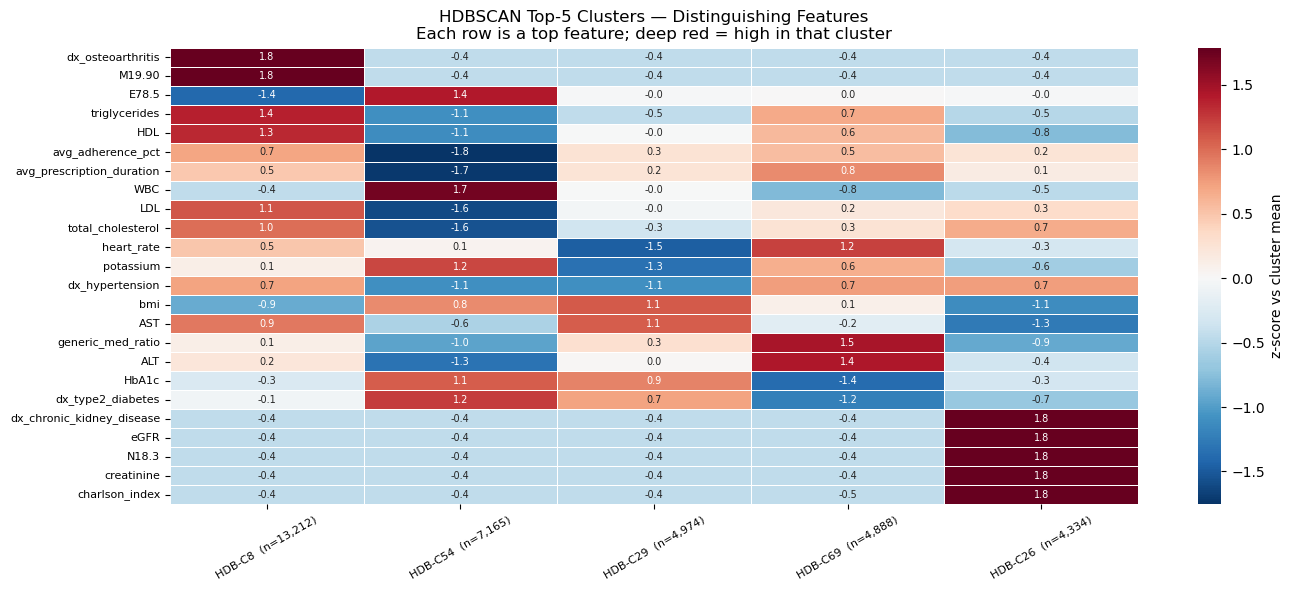

In [13]:
# ── HDBSCAN: top-5 largest clusters — z-score heatmap ────────────────────
from IPython.display import display

# ── top-5 cluster indices by size (noise excluded) ────────────────────────
top5 = (pd.Series(hdb_labels[hdb_labels != -1])
          .value_counts().head(5).index.tolist())
top5_keys = [f'HDB-C{c}' for c in top5]

# ── build z-score profile (same logic as K-Means heatmap) ────────────────
feat_cols = df.select_dtypes(include='number').columns.difference(['cluster']).tolist()
df_hdb    = df[feat_cols].copy()
df_hdb['hdb'] = hdb_labels

profile_hdb = df_hdb[df_hdb['hdb'].isin(top5)].groupby('hdb')[feat_cols].mean(numeric_only=True)
profile_hdb.index = top5_keys
pz_hdb = (profile_hdb - profile_hdb.mean()) / (profile_hdb.std() + 1e-9)

# ── union of top-N features per cluster ───────────────────────────────────
TOP_N_HDB = 5
top_feats = []
for key in top5_keys:
    top_feats += pz_hdb.loc[key].abs().nlargest(TOP_N_HDB).index.tolist()
top_feats = list(dict.fromkeys(top_feats))

# ── cluster labels with size ───────────────────────────────────────────────
labels = [f'{k}  (n={(hdb_labels == top5[i]).sum():,})' for i, k in enumerate(top5_keys)]
pz_focus = pz_hdb[top_feats].copy()
pz_focus.index = labels

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pz_focus.T, cmap='RdBu_r', center=0, linewidths=0.4,
            annot=True, fmt='.1f', annot_kws={'size': 7},
            ax=ax, cbar_kws={'label': 'z-score vs cluster mean'})
ax.set_title('HDBSCAN Top-5 Clusters — Distinguishing Features\n'
             'Each row is a top feature; deep red = high in that cluster')
ax.tick_params(axis='x', labelsize=8, rotation=30)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()


## K-Value Sensitivity Analysis

A natural question: are the visual and structural differences between K-Means and HDBSCAN
driven by the **choice of K** rather than the algorithm itself?

To test this, we fix the UMAP projection and refit K-Means with K = 10, 20, 40, 80, 96
(matching HDBSCAN's discovered cluster count), then compare K-Means K=96, GMM K=96,
and HDBSCAN side-by-side in the same projection.


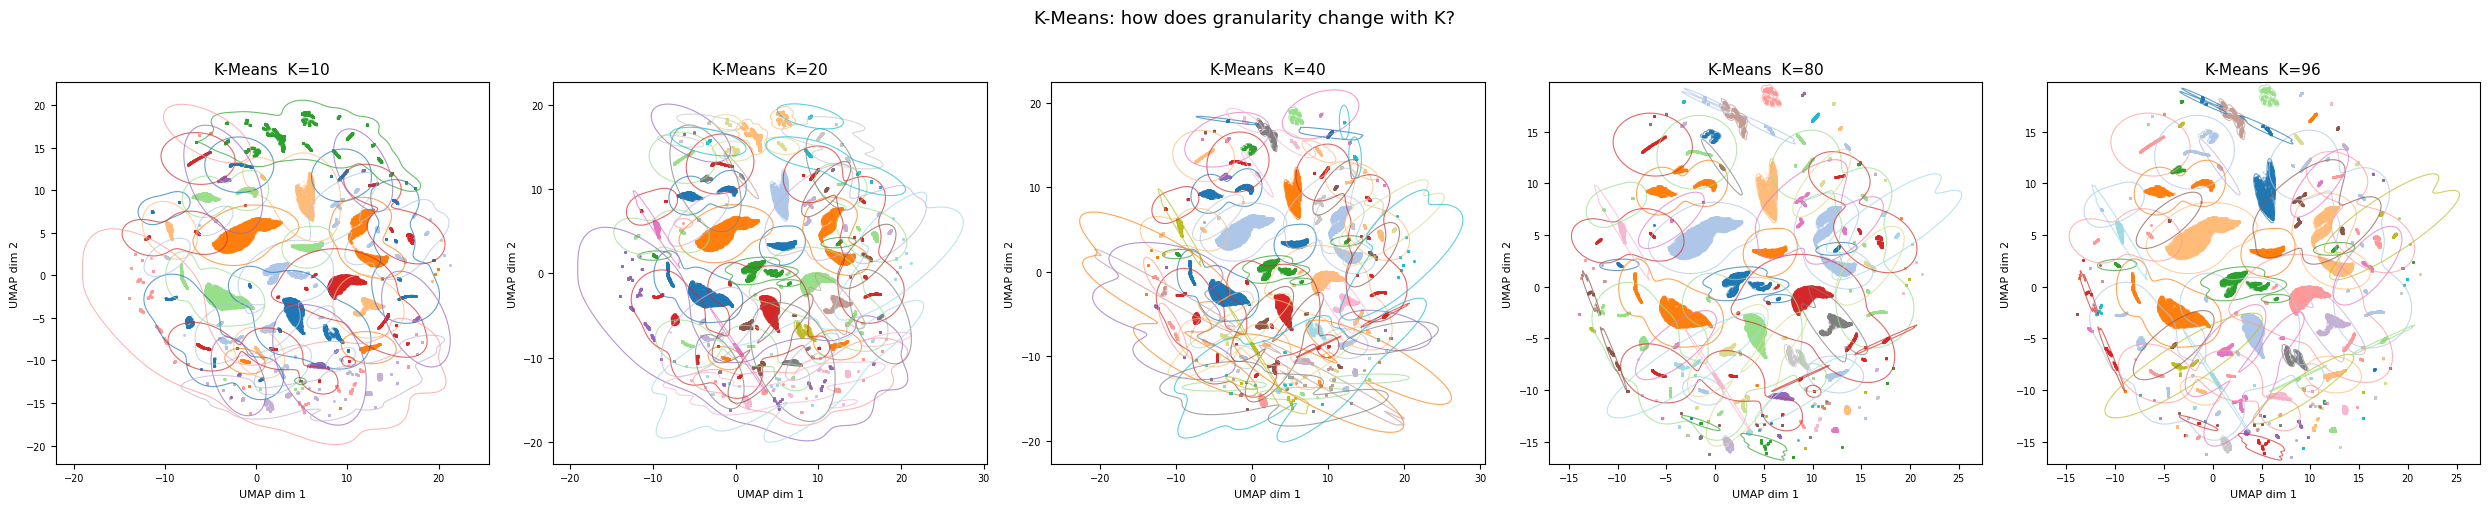

In [14]:
# ── K-Means sweep: K = 10, 20, 40, 80, 96 ───────────────────────────────────
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D

K_SWEEP = [10, 20, 40, 80, 96]
sweep_labels = {}

fig, axes = plt.subplots(1, len(K_SWEEP), figsize=(5 * len(K_SWEEP), 5))
cmap = plt.get_cmap('tab20')

for ax, k in zip(axes, K_SWEEP):
    km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=5, max_iter=300)
    labels = km_tmp.fit_predict(X_red)
    sweep_labels[k] = labels

    pal = [cmap(i % 20) for i in range(k)]
    for c in range(k):
        mask = labels == c
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   s=1, alpha=0.15, color=pal[c], rasterized=True)
        if mask.sum() > 400:
            try:
                import seaborn as sns_
                sns_.kdeplot(x=X_umap[mask, 0], y=X_umap[mask, 1], ax=ax,
                             color=pal[c], levels=2, linewidths=0.8, alpha=0.7)
            except Exception:
                pass
    ax.set_title(f'K-Means  K={k}', fontsize=11)
    ax.set_xlabel('UMAP dim 1', fontsize=8)
    ax.set_ylabel('UMAP dim 2', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('K-Means: how does granularity change with K?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Fitting GMM K=96  (may take a few minutes) ...


Done.


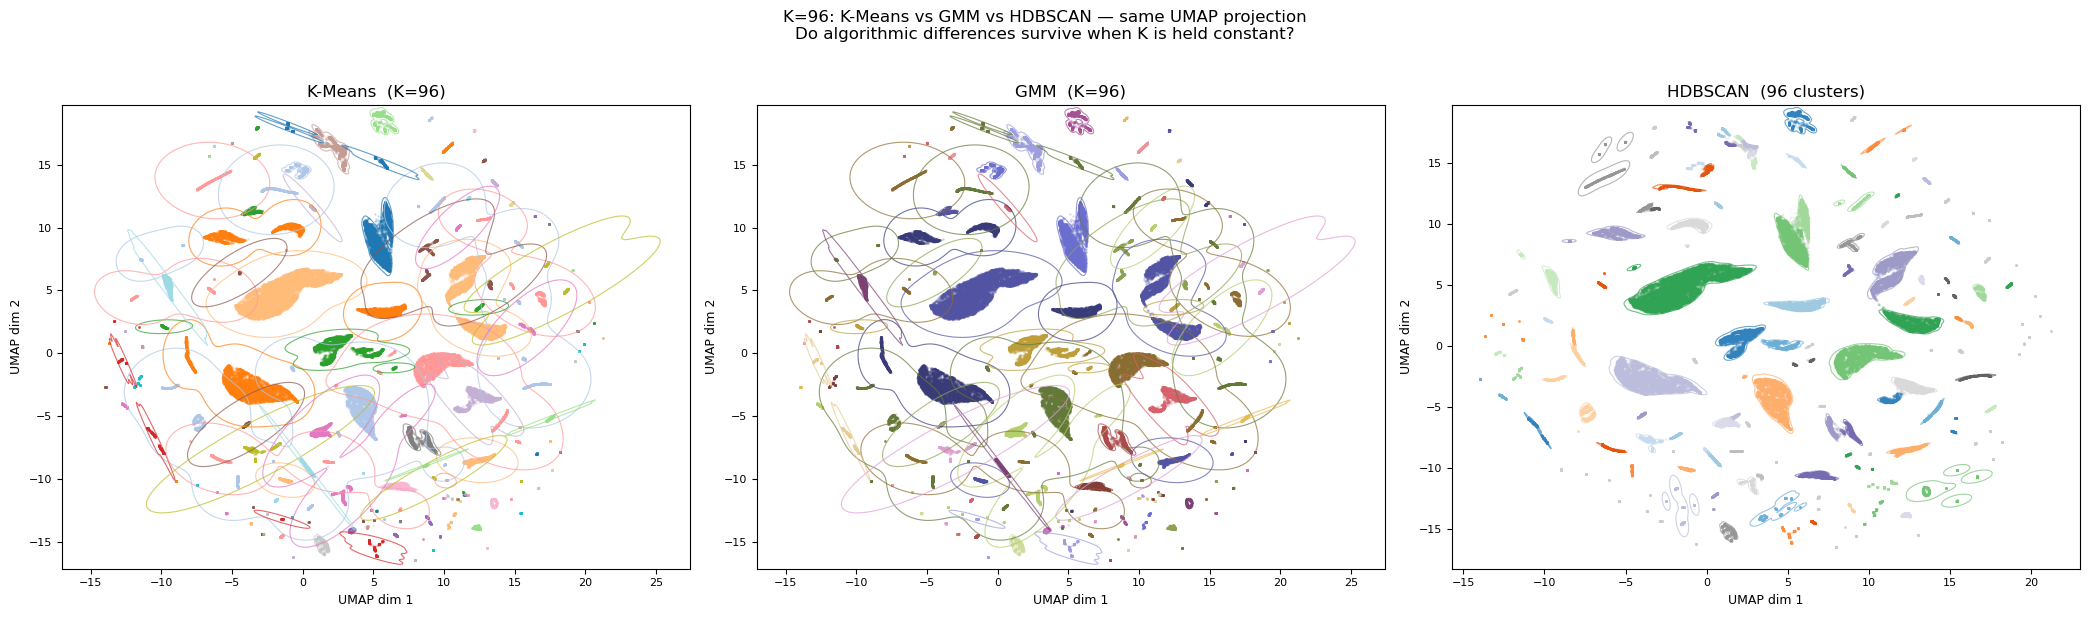

In [15]:
# ── K=96 head-to-head: K-Means | GMM | HDBSCAN ──────────────────────────────
from sklearn.mixture import GaussianMixture
from matplotlib.lines import Line2D
import seaborn as sns

K96 = 96

# -- K-Means K=96 (reuse from sweep) --
km96_labels = sweep_labels[K96]

# -- GMM K=96 --
print('Fitting GMM K=96  (may take a few minutes) ...')
gmm96 = GaussianMixture(n_components=K96, covariance_type='diag',
                         random_state=SEED, max_iter=300, n_init=1)
gmm96.fit(X_red)
gmm96_labels = gmm96.predict(X_red)
print('Done.')

# -- HDBSCAN labels already in hdb_labels --
titles = [f'K-Means  (K={K96})', f'GMM  (K={K96})', f'HDBSCAN  ({n_clusters} clusters)']
all_labels = [km96_labels, gmm96_labels, hdb_labels]
cmaps_ = ['tab20', 'tab20b', 'tab20c']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, lbl, title, cm in zip(axes, all_labels, titles, cmaps_):
    unique = sorted(set(lbl) - {-1})
    n_c    = len(unique)
    pal    = plt.get_cmap(cm)
    col_map = {c: pal(i % 20) for i, c in enumerate(unique)}

    if -1 in set(lbl):  # noise (HDBSCAN)
        mask = lbl == -1
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   s=1, alpha=0.1, color='#cccccc', rasterized=True)

    for c in unique:
        mask = lbl == c
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   s=1, alpha=0.15, color=col_map[c], rasterized=True)
        if mask.sum() > 400:
            try:
                sns.kdeplot(x=X_umap[mask, 0], y=X_umap[mask, 1], ax=ax,
                            color=col_map[c], levels=2, linewidths=0.8, alpha=0.7)
            except Exception:
                pass

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('UMAP dim 1', fontsize=9)
    ax.set_ylabel('UMAP dim 2', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle(
    f'K={K96}: K-Means vs GMM vs HDBSCAN — same UMAP projection\n'
    'Do algorithmic differences survive when K is held constant?',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [16]:
# ── Combined metrics: K-Means vs GMM vs HDBSCAN ──────────────────────────
# Silhouette / DB / CH — evaluated in 8-D feature space (same for all three)
# DBCV          — evaluated in 2-D UMAP space (same for all three, consistent)
from hdbscan import validity as hdbscan_validity
from IPython.display import display

idx10k  = np.random.choice(len(X_umap), size=10_000, replace=False)
# HDBSCAN DBCV only on non-noise points
valid_idx = np.where(hdb_labels != -1)[0]
idx_hdb_u = np.random.choice(valid_idx, size=min(10_000, len(valid_idx)), replace=False)

dbcv_km  = hdbscan_validity.validity_index(
               X_umap[idx10k].astype('float64'),  cluster_labels[idx10k], metric='euclidean')
dbcv_gmm = hdbscan_validity.validity_index(
               X_umap[idx10k].astype('float64'),  gmm_labels[idx10k],     metric='euclidean')
dbcv_hdb = hdbscan_validity.validity_index(
               X_umap[idx_hdb_u].astype('float64'), hdb_labels[idx_hdb_u], metric='euclidean')

km_full  = dict(km_metrics,  **{'DBCV (UMAP)': dbcv_km})
gmm_full = dict(gmm_metrics, **{'DBCV (UMAP)': dbcv_gmm})
hdb_full = dict(hdb_metrics, **{'DBCV (UMAP)': dbcv_hdb})

combined = pd.DataFrame({
    'K-Means (K=10)':                   km_full,
    'GMM (K=10)':                       gmm_full,
    f'HDBSCAN ({n_clusters} clusters)': hdb_full,
}).T.round(4)

display(combined.style
    .set_caption(
        'Clustering quality comparison  |  '
        'Silhouette/CH/DBCV ↑ better  |  DB ↓ better  |  '
        'DBCV computed in UMAP space; other metrics in 8-D feature space')
    .highlight_max(axis=0,
        subset=['Silhouette Score','Calinski-Harabasz Index','DBCV (UMAP)'],
        props='background-color:#d4edda')
    .highlight_min(axis=0,
        subset=['Davies-Bouldin Index'],
        props='background-color:#d4edda')
    .set_table_styles([
        {'selector':'th','props':[('text-align','center'),('font-size','11px')]},
        {'selector':'td','props':[('text-align','center'),('font-size','11px')]},
    ]))


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,DBCV (UMAP)
K-Means (K=10),0.681800,0.762200,3970.287600,-0.942900
GMM (K=10),0.688700,0.799300,3966.825400,-0.946800
HDBSCAN (96 clusters),0.107900,1.957000,1447.078100,0.489900


## Summary

We applied three clustering methods to 100,000 patients described by 8 FAMD-SVD components (≈90.7% variance retained).

| Method | K | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | DBCV (UMAP) ↑ |
|---|---|---|---|---|---|
| **K-Means** | 10 | 0.682 | **0.762** | **3970** | −0.943 |
| **GMM** | 10 | **0.689** | 0.799 | 3967 | −0.947 |
| **HDBSCAN** | 96 | 0.108 | 1.957 | 1447 | **+0.490** |

**K-Means vs GMM** — The two methods are statistically indistinguishable (Silhouette difference < 0.007, CH difference < 4). GMM's full-covariance model adds no measurable benefit because the disease-flag clusters are already near-spherical in the SVD space. K-Means is the simpler, equally effective choice.

**HDBSCAN** — Low Silhouette/DB/CH values are expected: with 96 micro-clusters, inter-cluster distances shrink, which structurally penalises centroid-based metrics. Its positive DBCV (+0.490 vs −0.94 for the other two) confirms it correctly finds density-connected regions rather than imposing arbitrary boundaries. The 3,503 noise-labelled patients (3.5%) identify the clinically complex cases that do not belong to any stable cohort — a capability neither K-Means nor GMM provides.
